## Notebook 9 – Outlier Detection

## What are Outliers?

### Concept
An outlier is a data point that's way different from the rest of the dataset, either much higher or much lower than most other values. It stands out enough that it's worth questioning whether it's a genuine extreme value or some kind of error in the data.

### Example
In a list of employee salaries where most people earn between 30K-50K, one entry showing 500K would be an outlier, it doesn't fit the general pattern of the rest of the data.

### Python Implementation

In [1]:
salaries = [32000, 35000, 40000, 38000, 42000, 500000]

mean_salary = sum(salaries) / len(salaries)
print("Mean salary (with outlier):", mean_salary)

salaries_no_outlier = salaries[:-1]
mean_no_outlier = sum(salaries_no_outlier) / len(salaries_no_outlier)
print("Mean salary (without outlier):", mean_no_outlier)

Mean salary (with outlier): 114500.0
Mean salary (without outlier): 37400.0


#### What the program does
This calculates the mean salary with and without that one extreme 500000 value, so we can directly see how much a single outlier can distort a simple average.

#### Key Point
An outlier is a value that doesn't fit the overall pattern of the rest of the data, and it can seriously distort simple statistics like the mean if left unchecked.

## Types of Outliers

### Concept
Outliers aren't all the same type. A Global Outlier is extreme compared to the entire dataset (like that 500K salary). A Contextual Outlier is only unusual in a specific context, like 35°C being completely normal in summer but an outlier if recorded in winter. A Collective Outlier is when a group of values together looks unusual, even if each one individually isn't extreme.

### Example
35°C temperature isn't an outlier in July, but the exact same 35°C reading in January would be a contextual outlier, since it depends on the surrounding context (the season), not just the raw number.

### Python Implementation

In [2]:
summer_temps = [30, 32, 33, 35, 31, 34]
winter_temps = [5, 7, 6, 8, 35, 6]  # 35 doesn't fit here at all

print("Is 35 unusual in summer?", 35 > max(summer_temps[:-1]))
print("Is 35 unusual in winter?", 35 > max([t for t in winter_temps if t != 35]))

Is 35 unusual in summer? False
Is 35 unusual in winter? True


#### What the program does
This compares the same value (35) against two different contexts, summer temperatures and winter temperatures, showing that whether something counts as an outlier depends on the surrounding data, not just the number itself.

#### Key Point
The same value can be completely normal or a clear outlier depending on context, which is why outlier detection isn't always just about a fixed numeric threshold.

## Detecting Outliers

### Concept
Detecting outliers just means actually identifying which values in a dataset qualify as outliers, using some systematic method rather than just eyeballing the numbers. The two most common statistical methods for this are the IQR Method and the Z-Score Method, both covered in detail next.

### Example
Instead of just looking at a list of 1000 numbers and guessing which ones look 'off', detecting outliers means applying a consistent rule (like IQR or Z-score) so the process is repeatable and not just a subjective guess.

### Python Implementation

In [3]:
data = [12, 14, 13, 15, 14, 13, 90, 12, 15, 14]

mean = sum(data) / len(data)
std_dev = (sum((x - mean) ** 2 for x in data) / len(data)) ** 0.5

outliers = [x for x in data if abs(x - mean) > 2 * std_dev]
print("Detected outliers:", outliers)

Detected outliers: [90]


#### What the program does
This flags any value that's more than 2 standard deviations away from the mean as an outlier, which is a simple, systematic rule instead of just visually scanning the list for anything that looks unusual.

#### Key Point
Outlier detection needs a consistent, repeatable method, not just a visual guess, which is exactly why statistical methods like IQR and Z-score exist.

## IQR Method

### Concept
The IQR Method flags a value as an outlier if it falls below Q1 − 1.5×IQR or above Q3 + 1.5×IQR, where IQR = Q3 − Q1 (covered in the Dispersion notebook). It's a robust method since it's based on the middle 50% of the data, not affected by the outliers it's trying to detect.

### Example
Marks: 55, 60, 62, 65, 68, 70, 72, 95. Q1 and Q3 are calculated from this, and anything falling outside the 1.5×IQR boundary (in this case, 95) gets flagged.

### Python Implementation

In [4]:
import numpy as np

marks = [55, 60, 62, 65, 68, 70, 72, 95]

q1 = np.percentile(marks, 25)
q3 = np.percentile(marks, 75)
iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = [x for x in marks if x < lower_bound or x > upper_bound]
print("Q1:", q1, " Q3:", q3, " IQR:", iqr)
print("Lower bound:", lower_bound, " Upper bound:", upper_bound)
print("Outliers:", outliers)

Q1: 61.5  Q3: 70.5  IQR: 9.0
Lower bound: 48.0  Upper bound: 84.0
Outliers: [95]


#### What the program does
This calculates Q1, Q3 and IQR first, then builds the lower and upper bound using the 1.5×IQR rule, and finally checks every mark against those bounds, flagging 95 since it falls above the upper bound.

#### Advantages
- Robust to outliers since it's based on the middle 50% of data, not affected by the extreme values it's trying to find.
- Doesn't require the data to follow any particular distribution shape.

#### Limitations
- The 1.5×IQR cutoff is a widely used convention, but it's still a somewhat arbitrary rule, not a hard mathematical law.

#### Key Point
The IQR Method flags outliers based on the spread of the middle 50% of data, making it reliable even when the data isn't normally distributed.

## Z-Score Method

### Concept
The Z-Score Method measures how many standard deviations a value is away from the mean, using Z = (x − mean) / standard deviation. A Z-score beyond +3 or -3 (sometimes +2/-2 depending on how strict you want to be) is typically flagged as an outlier. This method works best when the data is roughly normally distributed.

### Example
Marks: 55, 60, 62, 65, 68, 70, 72, 95

Calculating the Z-score for each value shows how far it sits from the mean in terms of standard deviations, and 95 ends up with a noticeably high Z-score compared to the rest.

### Python Implementation

In [5]:
import numpy as np

marks = [55, 60, 62, 65, 68, 70, 72, 95]

mean = np.mean(marks)
std_dev = np.std(marks)

z_scores = [(x - mean) / std_dev for x in marks]
outliers = [marks[i] for i in range(len(marks)) if abs(z_scores[i]) > 2]

print("Z-scores:", [round(z, 2) for z in z_scores])
print("Outliers (|Z| > 2):", outliers)

Z-scores: [np.float64(-1.18), np.float64(-0.74), np.float64(-0.56), np.float64(-0.3), np.float64(-0.03), np.float64(0.14), np.float64(0.32), np.float64(2.35)]
Outliers (|Z| > 2): [95]


#### What the program does
This calculates the Z-score for every mark, then flags any value whose Z-score magnitude is greater than 2 as an outlier, which correctly picks out 95 since it's noticeably far from the mean relative to the rest of the data's spread.

#### Advantages
- Simple to calculate and directly tells you how extreme a value is in standard deviation terms.

#### Limitations
- Only reliable when the data is roughly normally distributed, on skewed data it can miss real outliers or flag normal values incorrectly.

#### Key Point
The Z-Score Method flags outliers based on distance from the mean in standard deviations, but it works best specifically on normally distributed data.

## Box Plot

### Concept
A Box Plot is a visual way of showing Q1, median, Q3, and the IQR-based outlier boundaries all in one chart. Values outside the whiskers (the 1.5×IQR boundary) are shown as individual dots, making outliers immediately visible without calculating anything by hand.

### Example
The same marks data (55, 60, 62, 65, 68, 70, 72, 95) plotted as a box plot would show the box covering Q1 to Q3, a line for the median, whiskers extending to the normal range, and 95 appearing as a separate dot beyond the whisker.

### Python Implementation

C:\Users\rafiy\AppData\Local\Temp\ipykernel_15208\3581949337.py:6: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(marks, vert=False)


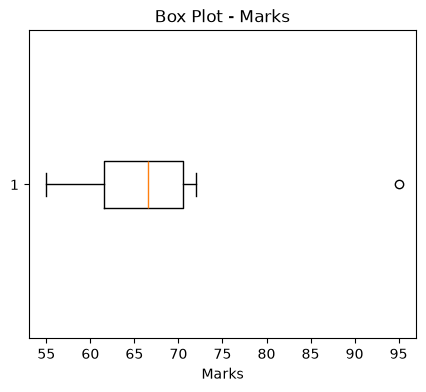

In [7]:
import matplotlib.pyplot as plt

marks = [55, 60, 62, 65, 68, 70, 72, 95]

plt.figure(figsize=(5,4))
plt.boxplot(marks, vert=False)
plt.title("Box Plot - Marks")
plt.xlabel("Marks")
plt.show()

#### What the program does
This plots the marks as a box plot, matplotlib automatically calculates Q1, Q3, the median, and the 1.5×IQR whisker boundaries internally, and draws whatever falls outside those boundaries as a separate point.

#### Why the graph looks like this
The box itself covers the middle 50% of the marks (Q1 to Q3), with a line inside marking the median. The whiskers stretch out to the last values still within the normal 1.5×IQR range, and 95 shows up as an isolated dot past the right whisker, because it's genuinely far outside where the rest of the data sits, exactly matching the IQR Method's calculation from before.

#### Key Point
A Box Plot visually represents the exact same boundaries the IQR Method calculates, making outliers obvious to spot at a glance.

## Scatter Plot

### Concept
A Scatter Plot plots individual data points on a graph, usually with two variables (x and y), which makes it easy to visually spot points that sit far away from the general cluster of the rest of the data, these isolated points are the outliers.

### Example
If most students' study hours and marks follow a clear upward pattern, but one student studied very little yet scored very high, that point would sit visibly apart from the rest of the cluster on a scatter plot.

### Python Implementation

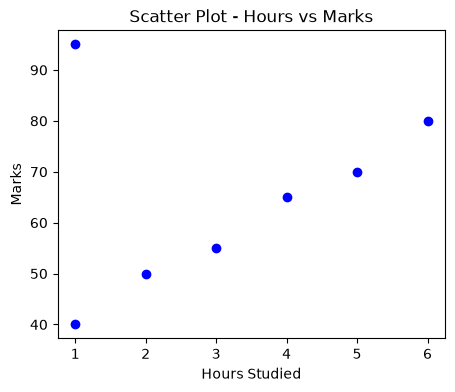

In [8]:
import matplotlib.pyplot as plt

hours = [1, 2, 3, 4, 5, 6, 1]
marks = [40, 50, 55, 65, 70, 80, 95]  # last point is an outlier (low hours, high marks)

plt.figure(figsize=(5,4))
plt.scatter(hours, marks, color="blue")
plt.title("Scatter Plot - Hours vs Marks")
plt.xlabel("Hours Studied")
plt.ylabel("Marks")
plt.show()

#### What the program does
This plots hours studied against marks scored for 7 students, where most points follow a clear upward pattern, letting us visually check where any point breaks from that pattern.

#### Why the graph looks like this
Most points form a fairly clean upward line from bottom-left to top-right, following the expected pattern of more hours leading to more marks. But the last point sits high up on the y-axis despite only 1 hour studied, visibly breaking away from the cluster the rest of the points form, which is exactly how a scatter plot makes an outlier stand out, not because of its value alone, but because it doesn't follow the relationship the other points share.

#### Key Point
A Scatter Plot makes outliers visible by showing which points break away from the general pattern formed by the rest of the data.

## Interview Questions

**1. What is an outlier?**</br>
An outlier is a data point that differs significantly from the rest of the dataset, either much higher or much lower than most other values, enough that it's worth questioning whether it's genuine or an error.

**2. What is the difference between the IQR Method and the Z-Score Method?**</br>
The IQR Method flags outliers based on Q1, Q3 and the middle 50% of the data, making it robust even when data isn't normally distributed. The Z-Score Method flags outliers based on how many standard deviations a value is from the mean, and works best specifically when the data is roughly normally distributed.

**3. Why is the IQR Method considered more robust than the Z-Score Method?**</br>
Because IQR is based on the median and quartiles, which aren't affected much by extreme values, while the Z-score calculation uses the mean and standard deviation, both of which can themselves be pulled around by the very outliers you're trying to detect.

**4. How does a Box Plot help in detecting outliers?**</br>
A Box Plot visually shows Q1, median, Q3 and the 1.5×IQR whisker boundaries, with any value outside those boundaries plotted as a separate point, making outliers immediately visible without manually calculating anything.

**5. What is the difference between a Global Outlier and a Contextual Outlier?**</br>
A Global Outlier is extreme compared to the entire dataset, regardless of context. A Contextual Outlier is only unusual within a specific context, like a certain season or category, the same value could be completely normal in a different context.

**6. Why can't you just remove every outlier you find in a dataset?**</br>
Not every outlier is a mistake, some are genuine, important extreme values (like a fraud transaction or a rare medical case), and removing them blindly could delete exactly the information that matters most for certain analyses or ML tasks like fraud or anomaly detection.